In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

pd.set_option('display.max_columns', None)

generated = Path('generated')

df_2022 = pd.read_parquet(generated / 'flights_2022_con_climas.parquet')

In [6]:
print(df_2022.shape)
display(df_2022)

(154586, 37)


,fecha_vuelo,aerolinea,aerolinea_dot,codigo_aerolinea,codigo_dot,numero_vuelo,origen,ciudad_origen,destino,ciudad_destino,hora_salida_programada,hora_salida_real,retraso_salida,tiempo_rodaje_salida,despegue,aterrizaje,tiempo_rodaje_llegada,hora_llegada_programada,hora_llegada_real,retraso_llegada,cancelado,codigo_cancelacion,desviado,duracion_programada,duracion_real,tiempo_en_aire,distancia,retraso_por_aerolinea,retraso_por_clima,retraso_por_trafico_aereo,retraso_por_seguridad,retraso_por_avion_tardio,mes,retrasado,temperatura_media,precipitacion,viento_max
0,2022-01-11,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,76,JFK,"New York, NY",SFO,"San Francisco, CA",700,651.0,-9.0,16.0,707.0,954.0,5.0,1053,959.0,-54.0,0.0,None,0.0,413.0,368.0,347.0,2586.0,NaN,NaN,NaN,NaN,NaN,1,0,-6.9,0.0,31.5
1,2022-01-11,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2883,ATL,"Atlanta, GA",GSP,"Greer, SC",1215,1210.0,-5.0,12.0,1222.0,1248.0,4.0,1308,1252.0,-16.0,0.0,None,0.0,53.0,42.0,26.0,153.0,NaN,NaN,NaN,NaN,NaN,1,0,3.1,0.0,23.8
2,2022-01-27,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1337,PHL,"Philadelphia, PA",MCO,"Orlando, FL",1700,1702.0,2.0,10.0,1712.0,1920.0,6.0,1940,1926.0,-14.0,0.0,None,0.0,160.0,144.0,128.0,861.0,NaN,NaN,NaN,NaN,NaN,1,0,-4.6,0.0,12.9
3,2022-01-11,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,4559,DAL,"Dallas, TX",TUL,"Tulsa, OK",1740,1736.0,-4.0,9.0,1745.0,1829.0,5.0,1845,1834.0,-11.0,0.0,None,0.0,65.0,58.0,44.0,238.0,NaN,NaN,NaN,NaN,NaN,1,0,6.5,0.4,18.6
4,2022-01-31,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2552,MSP,"Minneapolis, MN",TPA,"Tampa, FL",1840,1836.0,-4.0,15.0,1851.0,2228.0,5.0,2257,2233.0,-24.0,0.0,None,0.0,197.0,177.0,157.0,1306.0,NaN,NaN,NaN,NaN,NaN,1,0,-7.5,0.0,18.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154581,2022-12-20,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1366,IAD,"Washington, DC",DEN,"Denver, CO",825,824.0,-1.0,18.0,842.0,1009.0,10.0,1025,1019.0,-6.0,0.0,None,0.0,240.0,235.0,207.0,1452.0,NaN,NaN,NaN,NaN,NaN,12,0,-0.9,0.0,12.5
154582,2022-12-12,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1655,CLT,"Charlotte, NC",MKE,"Milwaukee, WI",1140,1136.0,-4.0,20.0,1156.0,1236.0,2.0,1247,1238.0,-9.0,0.0,None,0.0,127.0,122.0,100.0,651.0,NaN,NaN,NaN,NaN,NaN,12,0,7.4,0.0,12.2
154583,2022-12-09,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,2254,CHS,"Charleston, SC",DAL,"Dallas, TX",1305,1307.0,2.0,10.0,1317.0,1436.0,3.0,1455,1439.0,-16.0,0.0,None,0.0,170.0,152.0,139.0,977.0,NaN,NaN,NaN,NaN,NaN,12,0,15.8,3.1,14.7
154584,2022-12-16,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1388,DAL,"Dallas, TX",AMA,"Amarillo, TX",835,833.0,-2.0,8.0,841.0,945.0,4.0,950,949.0,-1.0,0.0,None,0.0,75.0,76.0,64.0,323.0,NaN,NaN,NaN,NaN,NaN,12,0,4.8,0.0,17.3


In [ ]:
# Los archivos parquet conservan el tipo de dato de cada columna.
df_2022['fecha_vuelo'].dt.day

0         11
1         11
2         27
3         11
4         31
          ..
154581    20
154582    12
154583     9
154584    16
154585    12
Name: fecha_vuelo, Length: 154586, dtype: int32

In [15]:
#Quiero separar en categóricas y numéricas, para poder hacer un análisis más profundo de los datos. 
categorical_columns = df_2022.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df_2022.select_dtypes(include=['int64', 'float64']).columns.tolist()

max_len = max(len(categorical_columns), len(numerical_columns))

columnas_frame = pd.DataFrame({
    'categoricas': categorical_columns + [''] * (max_len - len(categorical_columns)),
    'numericas': numerical_columns + [''] * (max_len - len(numerical_columns))
})

columnas_frame


,categoricas,numericas
0,aerolinea,codigo_dot
1,aerolinea_dot,numero_vuelo
2,codigo_aerolinea,hora_salida_programada
3,origen,hora_salida_real
4,ciudad_origen,retraso_salida
5,destino,tiempo_rodaje_salida
6,ciudad_destino,despegue
7,codigo_cancelacion,aterrizaje
8,,tiempo_rodaje_llegada
9,,hora_llegada_programada


In [8]:
# Conteo absoluto
conteo = df_2022['retrasado'].value_counts()
print("Conteo de vuelos:")
print(conteo)

# Porcentaje
porcentaje = df_2022['retrasado'].value_counts(normalize=True) * 100
print("\nPorcentaje de vuelos:")
print(porcentaje.round(2))

Conteo de vuelos:
retrasado
0    123038
1     31548
Name: count, dtype: int64

Porcentaje de vuelos:
retrasado
0    79.59
1    20.41
Name: proportion, dtype: float64


Por lo que podemos ver en esta parte del código podríamos decir que existe un desbalanceo de clases ya que el 20% del dataset son vuelos con retrasos y el otro 80% son vuelos que salieron a tiempo. Por lo que, a la hora de entrenar el modelo no deberíamos mirar únicamente el accuracy y además vamos a tener que realizar un balanceo de clases

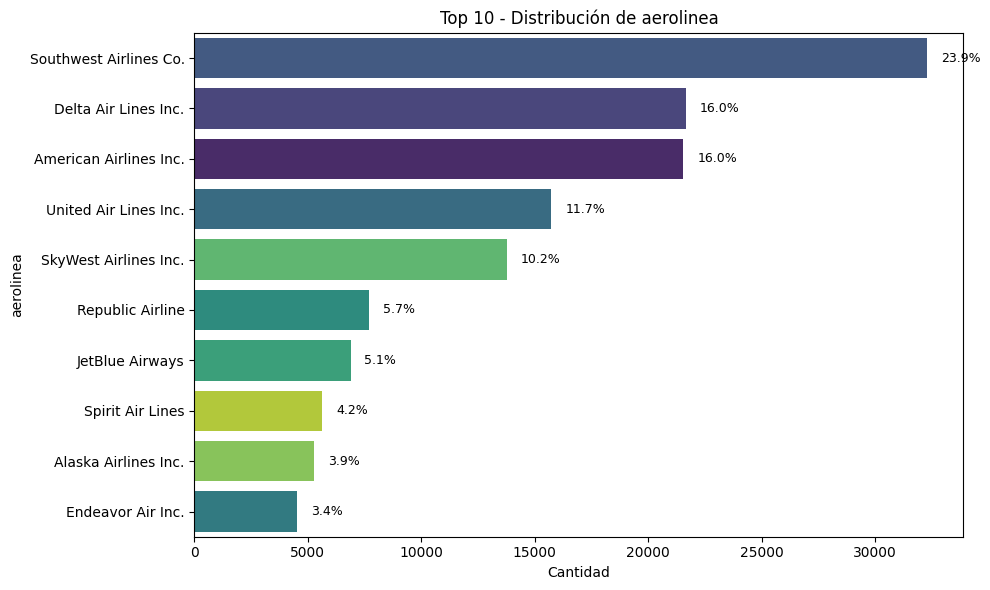

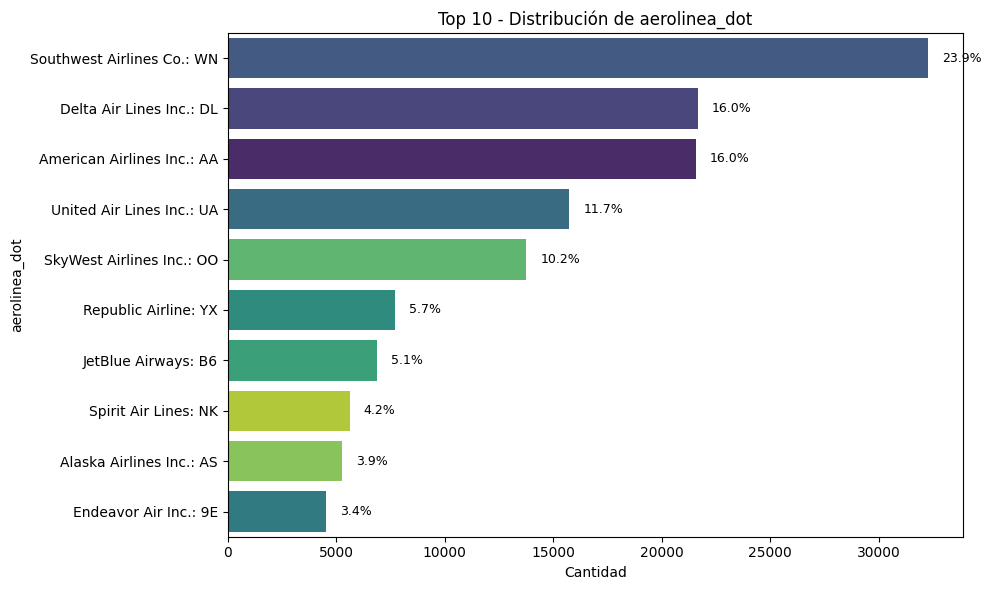

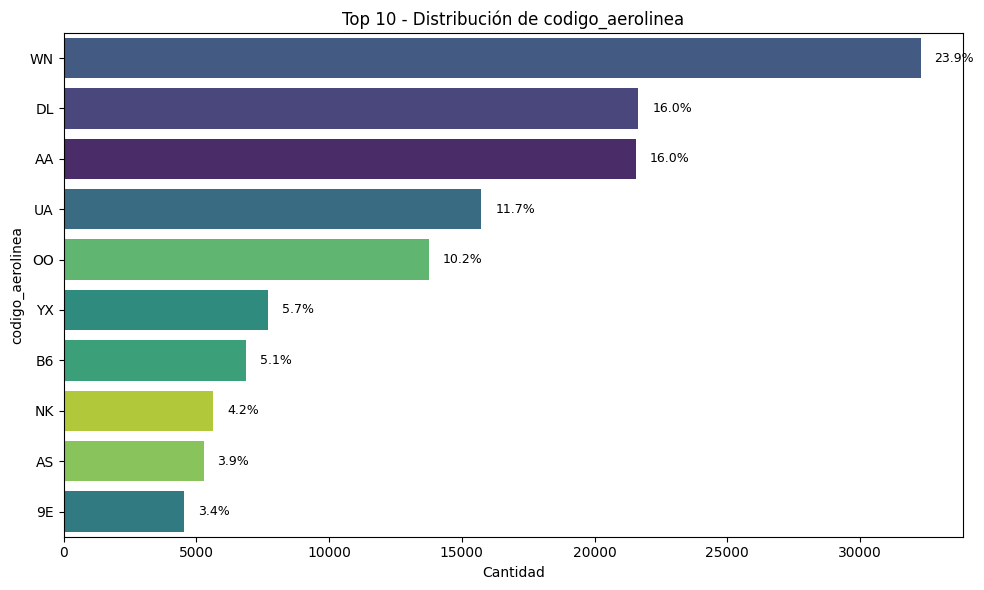

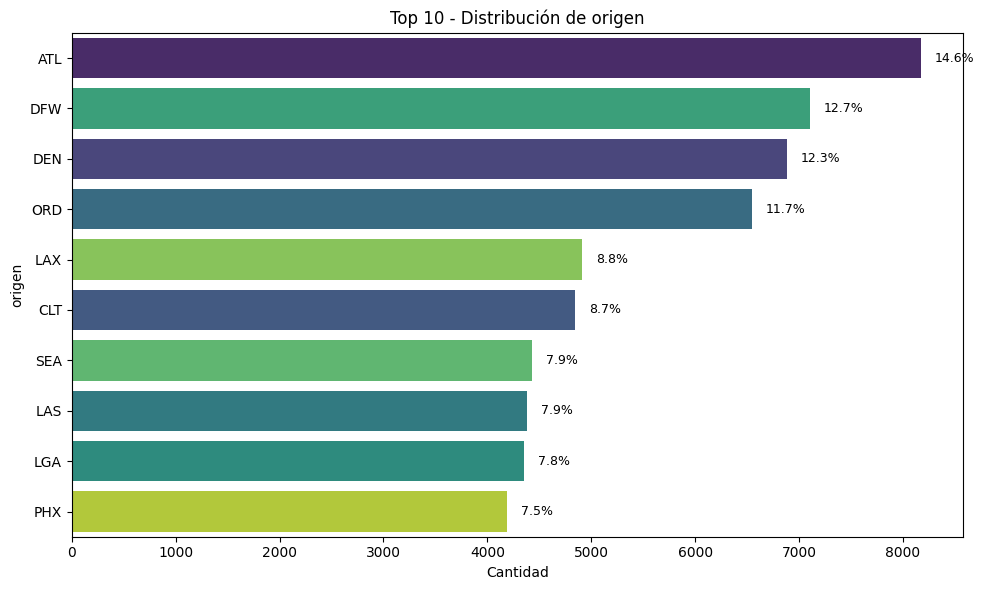

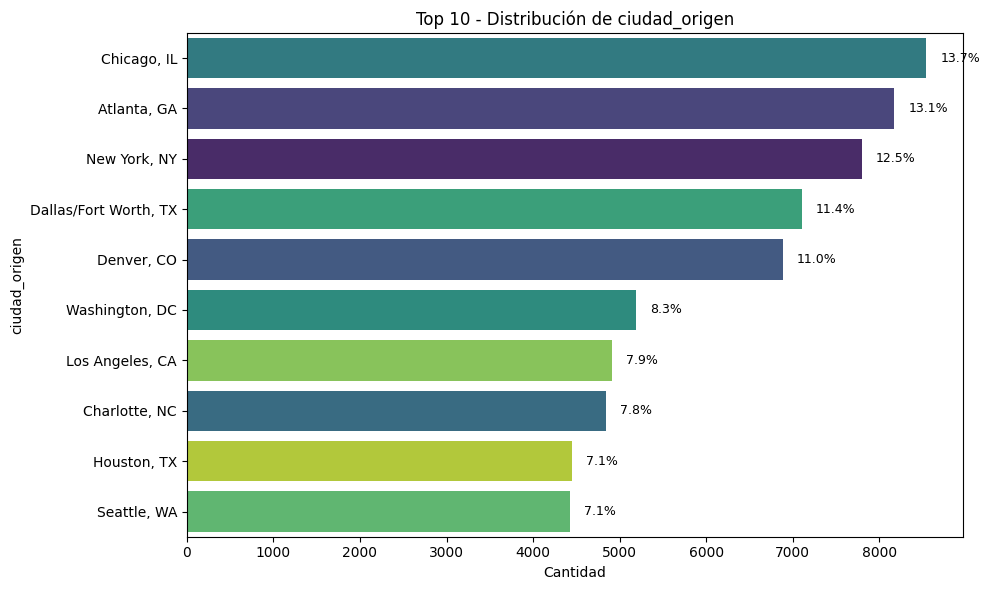

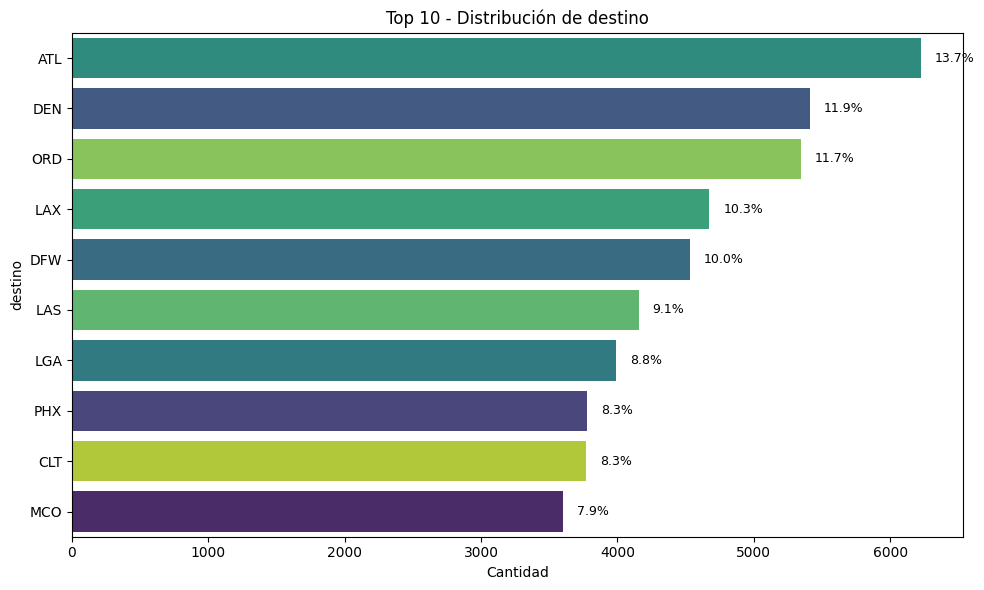

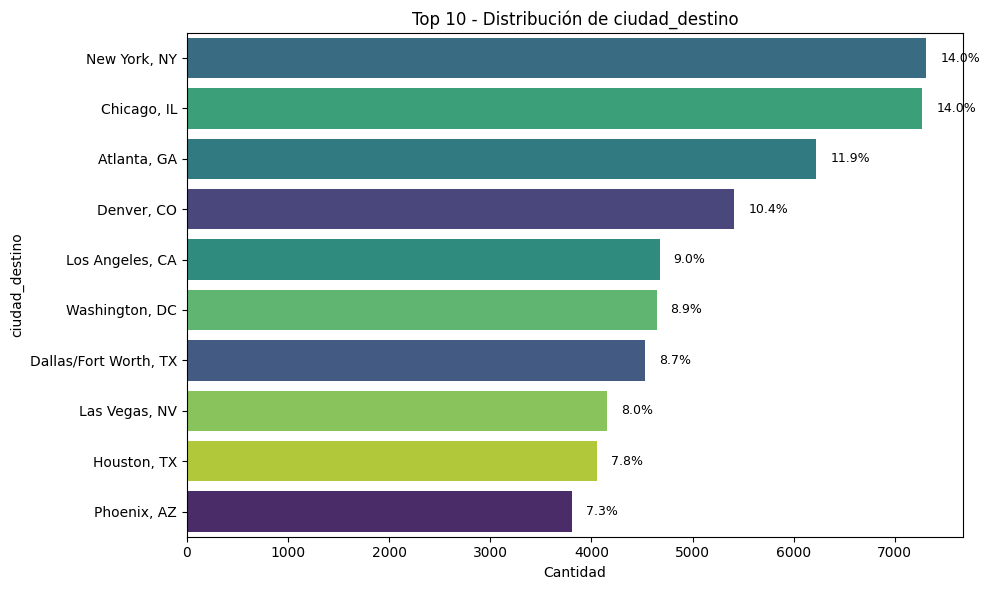

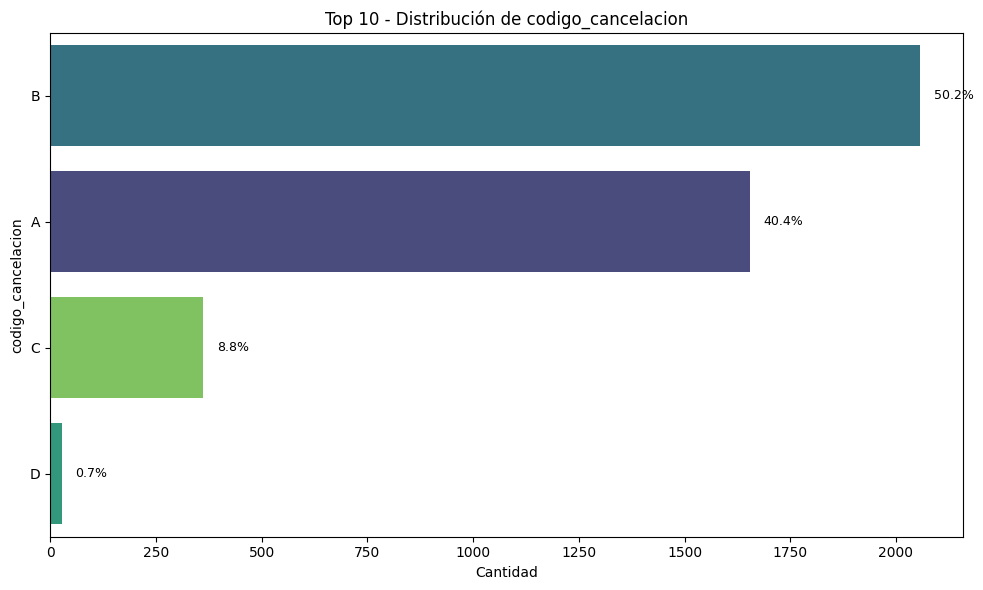

In [16]:
for col in categorical_columns:
    top10 = df_2022[col].value_counts().nlargest(10).index
    df_top10 = df_2022[df_2022[col].isin(top10)]

    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df_top10, y=col, hue=col, palette='viridis', legend=False, order=top10)
    plt.title(f'Top 10 - Distribución de {col}')
    plt.xlabel('Cantidad')
    plt.ylabel(col)

    total = len(df_top10)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.annotate(percentage, (x, y), ha='left', va='center', fontsize=9, color='black', xytext=(10, 0), textcoords='offset points')

    plt.tight_layout()
    plt.show()